# 05 - Evaluation, Monitoring and Deployment Readiness

Notebook 04 chose the model. This notebook asks the question that comes after the choice: **is it
safe to put into production, and how would we know when it stopped being safe?**

We take the scores notebook 04 wrote out, measure discrimination and calibration on the untouched
out-of-time window, cut a rating scale on `train` and apply it unchanged everywhere else, watch
institutions migrate between grades, and run a Population Stability Index over the whole panel. The
PSI is the centrepiece: it finds a genuine upstream data break in the month it happened.

Input: `Output/df_scores.parquet` (notebook 04) plus `Output/df_woe.parquet` (notebook 03) for the
two diagnostic sections. Outputs: `Output/ratings.xlsx`, `Output/psi.xlsx` and `figures/05_*.png`.

### Anticipated material, please read this first

**Session 8 (Evaluation, Monitoring and Deployment) hasn't been taught yet.** The rating scale, the
Population Stability Index, KS and the migration matrix below come from the conventions recorded in
the course reference notebook `00_` (Part 2) and from standard supervisory practice, not from a
lecture we've sat through. We flag every one of them as anticipated rather than taught, and where the
recorded convention doesn't fit this portfolio we report the mismatch instead of quietly adjusting
it.

**Scope.** The Point-in-Time macro overlay and its placebo test live in notebook 04 and aren't
repeated here. This notebook is evaluation, monitoring and deployment readiness only.

## 1. Setup

Same seed, same palette and the same `finish()` helper as notebook 04, writing to `figures/05_*.png`
at dpi 200 and showing each figure inline.

In [1]:
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_auc_score, roc_curve

SEED = 42
np.random.seed(SEED)

base_dir = pathlib.Path.cwd()
dir_output = base_dir / 'Output'
dir_figures = base_dir / 'figures'
dir_figures.mkdir(exist_ok=True)

pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 40)

NAVY, TEAL, AMBER = '#1F3A5F', '#2E7D8F', '#C8873B'
GREY, RED, GREEN = '#8895A3', '#B3402F', '#3E7D5A'
GRIDC = '#E6E9ED'

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': GREY, 'axes.labelcolor': '#333333',
    'axes.grid': True, 'grid.color': GRIDC, 'grid.linewidth': 0.8,
    'axes.axisbelow': True, 'font.size': 10,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'legend.frameon': False, 'xtick.color': '#333333', 'ytick.color': '#333333',
})


def finish(fig, name):
    """Despine, save to figures/05_<name>.png at dpi=200, then show inline."""
    for ax in fig.axes:
        sns.despine(ax=ax)
    path = dir_figures / f'05_{name}.png'
    fig.savefig(path, dpi=200, bbox_inches='tight')
    print(f'saved {path.name}')
    plt.show()


print(f'working directory: {base_dir}')

working directory: C:\Github_offline\Credit Risk Modelling\Final_Handover


## 2. The scored panel

`df_scores.parquet` carries one row per labelled institution-month with the three finalist scores
from notebook 04. Every score is `P(good)` on the course's `y_adj` convention, so a **high** score is
a **healthy** institution and `PD = 1 - score`.

We check the schema explicitly and raise on anything missing. A monitoring notebook that silently
falls back to a different column is exactly the failure mode monitoring exists to prevent.

In [2]:
SCORE_PATH = dir_output / 'df_scores.parquet'
REQUIRED = ['ID', 'DATA', 'sample', 'target', 'y_adj',
            'score_logit', 'score_tree', 'score_forest']

if not SCORE_PATH.exists():
    raise FileNotFoundError(f'{SCORE_PATH} not found - run notebook 04 first')

scores = pd.read_parquet(SCORE_PATH)
missing_cols = [c for c in REQUIRED if c not in scores.columns]
if missing_cols:
    raise KeyError(f'df_scores.parquet is missing required columns: {missing_cols}')
if scores[REQUIRED].isna().any().any():
    raise ValueError('df_scores.parquet contains nulls in a required column')

scores['pd_hat'] = 1.0 - scores['score_logit']
scores['year'] = scores['DATA'] // 100
scores['month'] = scores['DATA'] % 100

MODELS = {'Logit (WoE)': 'score_logit',
          'Tree entropy d=3': 'score_tree',
          'Forest d=4': 'score_forest'}
PRIMARY = 'score_logit'

print(f'df_scores : {scores.shape[0]:,} rows x {scores.shape[1]} columns')
print(f'periods   : {scores["DATA"].min()} to {scores["DATA"].max()}  (integer YYYYMM)')
print(f'institutions : {scores["ID"].nunique()}')
print(scores.head(3).round(4).to_string(index=False))

df_scores : 13,666 rows x 11 columns
periods   : 201703 to 202603  (integer YYYYMM)
institutions : 221
      ID   DATA sample  target  y_adj  score_logit  score_tree  score_forest  pd_hat  year  month
C0080329 201703  train       0      1       0.9765      0.8485        0.8262  0.0235  2017      3
C0080288 201703  train       0      1       0.9765      0.8485        0.8262  0.0235  2017      3
C0080446 201703  train       0      1       0.7685      0.3704        0.3053  0.2315  2017      3


### 2.1 Samples, and how we're allowed to count events

`train` fitted the model, `oot` judges it, `mr` is the monitoring window. We assert the split so the
run fails loudly rather than reporting a different portfolio under the same headline.

**Counting rule, applied everywhere in this notebook.** A bad "event" here is an
institution-**month**, and those months repeat heavily within the same institution, so we always
report both numbers: *"207 institution-months from 23 conglomerates"*, never "207 events".

In [3]:
split = (scores.groupby('sample')
                .agg(rows=('target', 'size'), bad=('target', 'sum'),
                     institutions=('ID', 'nunique'),
                     first=('DATA', 'min'), last=('DATA', 'max')))
split['bad_institutions'] = (scores[scores['target'] == 1]
                             .groupby('sample')['ID'].nunique())
split['bad_rate'] = split['bad'] / split['rows']
split = split.loc[['train', 'oot', 'mr']]

print(split.assign(bad_rate=lambda d: d['bad_rate'].map('{:.2%}'.format)).to_string())

EXPECTED_SPLIT = {'train': (7975, 680, 36, 201703, 202212),
                  'oot':   (1737, 207, 23, 202301, 202312),
                  'mr':    (3954, 362, 31, 202401, 202603)}
for name, expected in EXPECTED_SPLIT.items():
    got = (int(split.loc[name, 'rows']), int(split.loc[name, 'bad']),
           int(split.loc[name, 'bad_institutions']),
           int(split.loc[name, 'first']), int(split.loc[name, 'last']))
    if got != expected:
        raise AssertionError(f'{name}: expected {expected}, got {got}')
print('\nsplit matches the specification agreed for the report')

train = scores[scores['sample'] == 'train'].copy()
oot = scores[scores['sample'] == 'oot'].copy()
mr = scores[scores['sample'] == 'mr'].copy()

        rows  bad  institutions   first    last  bad_institutions bad_rate
sample                                                                    
train   7975  680           167  201703  202212                36    8.53%
oot     1737  207           157  202301  202312                23   11.92%
mr      3954  362           186  202401  202603                31    9.16%

split matches the specification agreed for the report


The out-of-time year carries **207 bad institution-months from 23 conglomerates** across 1,737
rows and 157 institutions, and 17 of those 23 contribute all twelve months. That's the sample every
out-of-time number below rests on, and it's small enough that we treat differences under about
0.01 AUC as noise.

### 2.2 The diagnostic frame

Two sections need variables `df_scores` doesn't carry: the WoE bins (to show *why* the PSI alarm
fires) and the raw `E01` ratio (to show a calendar artefact in the score level). We load them from
notebook 03's frame and join on the panel key, raising if the join isn't exact.

In [4]:
WOE_COLS = (['ID', 'DATA', 'predicted_good', 'A01_woe', 'M01_woe', 'E01_woe', 'L01_woe',
             'A01', 'M01', 'E01', 'L01', 'target', 'sample']
            + [f'b{k}_I_linear' for k in range(1, 13)])

woe = pd.read_parquet(dir_output / 'df_woe.parquet', columns=WOE_COLS)
diag = scores.merge(woe.drop(columns=['target', 'sample']), on=['ID', 'DATA'], how='left',
                    validate='one_to_one')
if diag['predicted_good'].isna().any():
    raise ValueError('df_scores contains rows absent from df_woe - the panels have drifted apart')

corr = diag['score_logit'].corr(diag['predicted_good'])
print(f'diagnostic frame : {diag.shape[0]:,} rows x {diag.shape[1]} columns')
print(f'corr(score_logit, notebook 03 predicted_good) = {corr:.4f}')

diagnostic frame : 13,666 rows x 32 columns
corr(score_logit, notebook 03 predicted_good) = 0.9990


`score_logit` and notebook 03's `predicted_good` are the same specification fitted on slightly
different rows (notebook 04 drops the redundant inner 70/30 split), and they correlate at 0.999. We
rate on `score_logit` throughout, because that's the model notebook 04 actually selected.

## 3. Discrimination

AUC, Gini `= 2 x AUC - 1` and KS `= max(TPR - FPR)` for the three models on all three samples. KS is
computed off the ROC curve, which is the same convention notebook 04 used, so the two notebooks
agree to the fourth decimal.

In [5]:
def ks_stat(y_true, score):
    """Kolmogorov-Smirnov = maximum separation between the good and bad score CDFs."""
    fpr, tpr, _ = roc_curve(y_true, score)
    return float(np.max(tpr - fpr))


rows = []
for name, column in MODELS.items():
    row = {'model': name}
    for tag, frame in (('train', train), ('oot', oot), ('mr', mr)):
        row[f'{tag}_AUC'] = roc_auc_score(frame['y_adj'], frame[column])
    row['oot_Gini'] = 2 * row['oot_AUC'] - 1
    row['oot_KS'] = ks_stat(oot['y_adj'], oot[column])
    row['mr_KS'] = ks_stat(mr['y_adj'], mr[column])
    rows.append(row)

discrimination = pd.DataFrame(rows).set_index('model')
print(discrimination.round(4).to_string())

                  train_AUC  oot_AUC  mr_AUC  oot_Gini  oot_KS   mr_KS
model                                                                 
Logit (WoE)          0.8138   0.8652  0.6850    0.7304  0.5838  0.3278
Tree entropy d=3     0.8000   0.8551  0.6742    0.7102  0.5759  0.2990
Forest d=4           0.8339   0.8620  0.6902    0.7241  0.6093  0.3304


The primary scorecard reaches **oot AUC 0.8652, Gini 0.7304, KS 0.5838** on a year it never saw.
That's above the ~0.84 Session 7 slide 29 quotes for gradient boosting on standard credit datasets,
and above its own training AUC of 0.8138. The forest is 0.003 behind on AUC and ahead on KS, which is
the tie notebook 04 established formally. Every model loses roughly 0.18 AUC on `mr`, and section 8
shows that's a data break rather than a model failure.

### 3.1 ROC and KS on the out-of-time window

The ROC curve is the whole ranking. The KS curve is the single threshold where the good and bad
distributions sit furthest apart, which is what a cut-off discussion actually needs.

saved 05_roc_ks_oot.png


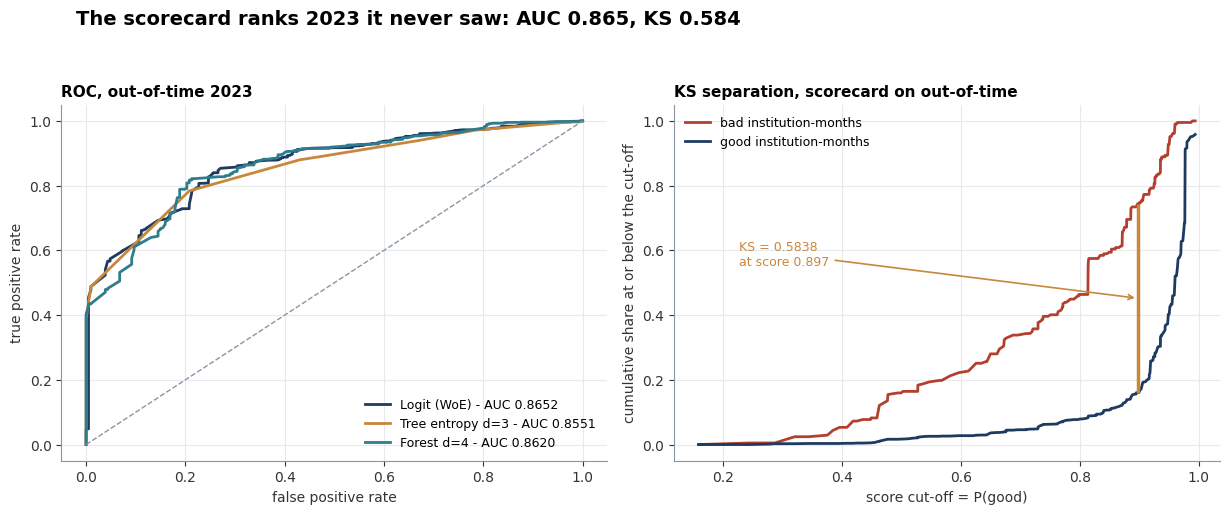

at the KS cut-off (score 0.897): 74.4% of bad institution-months sit below it, against 16.0% of good ones
a review queue at that cut-off = 23.0% of the sample (399 of 1737 rows), 38.6% of them bad


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 5.2))

ax = axes[0]
for (name, column), colour in zip(MODELS.items(), (NAVY, AMBER, TEAL)):
    fpr, tpr, _ = roc_curve(oot['y_adj'], oot[column])
    ax.plot(fpr, tpr, color=colour, lw=2,
            label=f'{name} - AUC {discrimination.loc[name, "oot_AUC"]:.4f}')
ax.plot([0, 1], [0, 1], color=GREY, ls='--', lw=1)
ax.set_xlabel('false positive rate')
ax.set_ylabel('true positive rate')
ax.set_title('ROC, out-of-time 2023', fontsize=11)
ax.legend(loc='lower right', fontsize=9)

ax = axes[1]
# Read the KS off the same ROC curve the table uses, so tied scores are grouped identically
# and the two numbers agree. Dropping the first point removes the artificial +inf threshold.
fpr, tpr, thresholds = roc_curve(oot['y_adj'], oot[PRIMARY])
fpr, tpr, thresholds = fpr[1:], tpr[1:], thresholds[1:]
cum_bad, cum_good = 1 - fpr, 1 - tpr
gap = tpr - fpr
cut = int(np.argmax(gap))

ax.plot(thresholds, cum_bad, color=RED, lw=2, label='bad institution-months')
ax.plot(thresholds, cum_good, color=NAVY, lw=2, label='good institution-months')
ax.vlines(thresholds[cut], cum_good[cut], cum_bad[cut], color=AMBER, lw=2.5)
ax.annotate(f'KS = {gap[cut]:.4f}\nat score {thresholds[cut]:.3f}',
            xy=(thresholds[cut], (cum_bad[cut] + cum_good[cut]) / 2),
            xytext=(0.12, 0.55), textcoords='axes fraction', fontsize=9, color=AMBER,
            arrowprops=dict(arrowstyle='->', color=AMBER, lw=1.2))
ax.set_xlabel('score cut-off = P(good)')
ax.set_ylabel('cumulative share at or below the cut-off')
ax.set_title('KS separation, scorecard on out-of-time', fontsize=11)
ax.legend(loc='upper left', fontsize=9)

fig.suptitle('The scorecard ranks 2023 it never saw: AUC 0.865, KS 0.584',
             x=0.065, ha='left', fontsize=14, fontweight='bold')
fig.tight_layout(rect=(0, 0, 1, 0.93))
finish(fig, 'roc_ks_oot')

print(f'at the KS cut-off (score {thresholds[cut]:.3f}): {cum_bad[cut]:.1%} of bad '
      f'institution-months sit below it, against {cum_good[cut]:.1%} of good ones')
queue = oot[oot[PRIMARY] < thresholds[cut]]
print(f'a review queue at that cut-off = {len(queue) / len(oot):.1%} of the sample '
      f'({len(queue)} of {len(oot)} rows), {queue["target"].mean():.1%} of them bad')

At the KS cut-off the scorecard has already captured **74.4% of the bad institution-months while
touching only 16.0% of the good ones**. In practice, a review queue built there would look at 23% of
the portfolio and find a genuine bad case in about two of every five institution-months it opened,
against a base rate of 11.9%.

### 3.2 Robustness: institution-months with a truncated forward window

The target looks twelve months forward, but at the edge of an institution's IF.Data coverage that
window is only partly observable. Notebook 02 labels such a row bad whenever it's **already** in
breach and leaves it unlabelled otherwise, so at the coverage edge only *bad* rows can acquire a
label. We measure what that asymmetry is worth by re-running the evaluation on the subset whose
twelve forward months are fully observable.

In [7]:
B_COLS = [f'b{k}_I_linear' for k in range(1, 13)]
diag['forward_obs'] = diag[B_COLS].notna().sum(axis=1)

zero_window = diag[diag['forward_obs'] == 0]
print(f'labelled rows with NO observable forward month : {len(zero_window)}')
print(f'   of which labelled bad                        : {int(zero_window["target"].sum())}')

truncated = diag[diag['forward_obs'] < 12]
full = diag[diag['forward_obs'] == 12]
print(f'\ntruncated window (<12 months): {len(truncated):,} rows, '
      f'bad rate {truncated["target"].mean():.1%}')
print(f'full window      (12 months) : {len(full):,} rows, bad rate {full["target"].mean():.1%}')

sens = []
for tag in ('train', 'oot', 'mr'):
    everything = diag[diag['sample'] == tag]
    observed = everything[everything['forward_obs'] == 12]
    sens.append({
        'sample': tag,
        'rows': len(everything), 'bad': int(everything['target'].sum()),
        'bad_inst': everything.loc[everything['target'] == 1, 'ID'].nunique(),
        'AUC': roc_auc_score(everything['y_adj'], everything[PRIMARY]),
        'rows_full': len(observed), 'bad_full': int(observed['target'].sum()),
        'bad_inst_full': observed.loc[observed['target'] == 1, 'ID'].nunique(),
        'AUC_full': roc_auc_score(observed['y_adj'], observed[PRIMARY]),
    })
sensitivity = pd.DataFrame(sens).set_index('sample')
print()
print(sensitivity.round(4).to_string())

labelled rows with NO observable forward month : 31
   of which labelled bad                        : 31

truncated window (<12 months): 2,539 rows, bad rate 15.6%
full window      (12 months) : 11,127 rows, bad rate 7.7%

        rows  bad  bad_inst     AUC  rows_full  bad_full  bad_inst_full  AUC_full
sample                                                                           
train   7975  680        36  0.8138       7583       581             29    0.8116
oot     1737  207        23  0.8652       1491       107             18    0.8756
mr      3954  362        31  0.6850       2053       165             22    0.6694


**31 labelled rows have no observable forward month at all, and all 31 are labelled bad.** The
asymmetry is real and we're not hiding it. Requiring a fully observable window takes `oot` from
**207 bad institution-months from 23 conglomerates to 107 from 18**, and yet out-of-time AUC *rises*
from 0.8652 to 0.8756. The ranking doesn't depend on the truncated rows, which is the reassuring
version of this finding, and it's why we report the headline on the full sample with this sensitivity
attached rather than re-cutting the panel.

## 4. Calibration

Discrimination is about **order**. Calibration is about **level**: does a predicted PD of 5% come
true 5% of the time? A logistic regression is calibrated by construction on the sample it was fitted
on, so `train` tells us nothing. The question is whether the level survives out of time.

In [8]:
level = []
for tag, frame in (('train', train), ('oot', oot), ('mr', mr)):
    level.append({'sample': tag, 'rows': len(frame),
                  'predicted_PD': frame['pd_hat'].mean(),
                  'observed_bad_rate': frame['target'].mean()})
level = pd.DataFrame(level).set_index('sample')
level['ratio'] = level['observed_bad_rate'] / level['predicted_PD']
print(level.round(4).to_string())

oot_cal = oot.copy()
oot_cal['decile'] = pd.qcut(oot_cal['pd_hat'], 10, labels=False, duplicates='drop')
reliability = (oot_cal.groupby('decile')
                      .agg(rows=('target', 'size'), institutions=('ID', 'nunique'),
                           predicted_PD=('pd_hat', 'mean'),
                           observed=('target', 'mean'), bad=('target', 'sum')))
print()
print(reliability.round(4).to_string())

        rows  predicted_PD  observed_bad_rate   ratio
sample                                               
train   7975        0.0853             0.0853  1.0000
oot     1737        0.0966             0.1192  1.2338
mr      3954        0.0891             0.0916  1.0274

        rows  institutions  predicted_PD  observed  bad
decile                                                 
0        483            69        0.0203    0.0021    1
1         59            15        0.0259    0.0000    0
2        154            35        0.0316    0.0000    0
3        180            46        0.0411    0.0444    8
4        168            49        0.0541    0.0952   16
5        189            53        0.0734    0.1005   19
6        158            44        0.0994    0.1519   24
7        175            56        0.1770    0.3371   59
8        171            34        0.4358    0.4678   80


On `train` the predicted and observed bad rates agree to four decimals (8.53% both), as they have
to. On `oot` the model predicts **9.66%** against an observed **11.92%**, so it **under-predicts the
level by about a fifth**, because 2023 was a harder year than the ones it was fitted on. The order is
right, with the observed rate rising across the deciles from 0.2% to 46.8%, but the level isn't: the
three safest deciles come in *below* their prediction and the three riskiest come in well above it,
decile 8 predicting 17.7% against an observed 33.7%. The first decile is wide (483 rows) because the
score is discrete and equal-frequency cuts can't split a tied score.

saved 05_calibration_oot.png


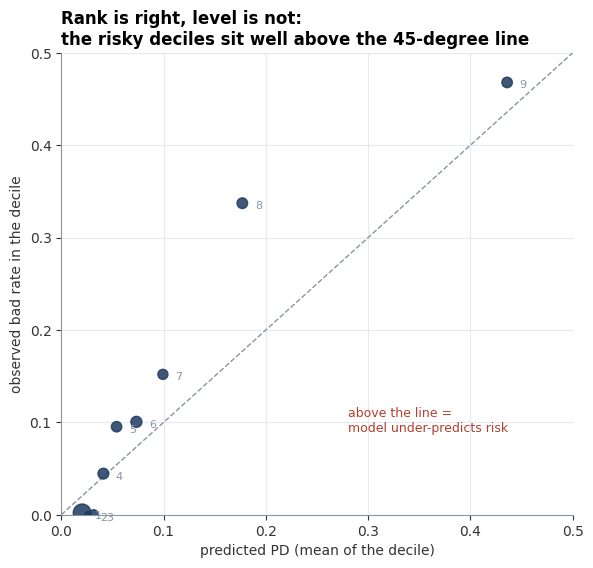

In [9]:
fig, ax = plt.subplots(figsize=(6.6, 6.0))
ax.plot([0, 0.5], [0, 0.5], color=GREY, ls='--', lw=1)
ax.scatter(reliability['predicted_PD'], reliability['observed'],
           s=reliability['rows'] / 3, color=NAVY, alpha=0.85, zorder=3)
for decile, row in reliability.iterrows():
    ax.annotate(f'{int(decile) + 1}', (row['predicted_PD'], row['observed']),
                textcoords='offset points', xytext=(9, -4), fontsize=8, color=GREY)
ax.set_xlabel('predicted PD (mean of the decile)')
ax.set_ylabel('observed bad rate in the decile')
ax.set_title('Rank is right, level is not:\n'
             'the risky deciles sit well above the 45-degree line')
ax.text(0.28, 0.09, 'above the line =\nmodel under-predicts risk',
        fontsize=9, color=RED)
ax.set_xlim(0, 0.5)
ax.set_ylim(0, 0.5)
finish(fig, 'calibration_oot')

The claim a WoE scorecard makes is **ranking**, and the reliability plot supports it: the observed
rate is monotone across the deciles apart from the tied low-risk block. The level isn't
production-ready as a PD. It would need a central-tendency recalibration, meaning a scaling of the
intercept to the realised portfolio bad rate, before it could feed provisioning or pricing. We'd
rather say that than present `1 - score` as a PD estimate.

## 5. The course rating scale, applied as documented

The convention recorded in `00_` Part 2 cuts `predicted_good` at fixed edges:
`<= 0.17 -> 8, <= 0.24 -> 7, <= 0.33 -> 6, <= 0.44 -> 5, <= 0.57 -> 4, <= 0.69 -> 3, <= 0.85 -> 2,
else 1`, with the note that 8 is the best grade. We apply it unchanged to the primary score and
measure what it does to this portfolio.

In [10]:
COURSE_EDGES = [-0.001, 0.17, 0.24, 0.33, 0.44, 0.57, 0.69, 0.85, 1.001]
COURSE_LABELS = [8, 7, 6, 5, 4, 3, 2, 1]

scores['course_grade'] = pd.cut(scores[PRIMARY], COURSE_EDGES,
                                labels=COURSE_LABELS).astype(int)

course_table = (scores[scores['sample'] == 'train']
                .groupby('course_grade')
                .agg(rows=('target', 'size'), bad=('target', 'sum'),
                     institutions=('ID', 'nunique')))
course_table['share_%'] = course_table['rows'] / course_table['rows'].sum() * 100
course_table['bad_rate_%'] = course_table['bad'] / course_table['rows'] * 100
course_table.index.name = 'course grade'
print(course_table.round(2).to_string())

              rows  bad  institutions  share_%  bad_rate_%
course grade                                              
1             6837  320           161    85.73        4.68
2              628  152            80     7.87       24.20
3              261   84            51     3.27       32.18
4              177   81            37     2.22       45.76
5               53   28            17     0.66       52.83
6               14   10             7     0.18       71.43
7                1    1             1     0.01      100.00
8                4    4             1     0.05      100.00


**Two problems with it, both of which we report rather than silently fix.**

**(1) The orientation is inverted on this portfolio.** The recorded note says 8 is the best grade,
but the measured bad rate rises monotonically *with* the grade number: **4.68% at grade 1 and 100% at
grades 7 and 8**. That's arithmetically inevitable. `predicted_good` is P(good), so the *lowest*
scores are the *riskiest*, and the scale maps the lowest band to grade 8. Either the note's "8 =
best" is a slip, or the edges were written for a score oriented as P(bad). That's an ambiguity to
raise with the instructor rather than something to patch quietly.

**(2) The fixed edges don't fit this score distribution.** Grade 1 holds **85.7%** of the training
portfolio and grades 5-8 hold 0.9% between them, 5 rows of which carry grades 7 and 8. A scale that
puts six institutions in seven into a single bucket can't support limit-setting, pricing or a
concentration report, and a 100% bad rate computed on one row isn't an estimate of anything. The
edges were presumably calibrated on a score distribution with far more spread than ours.

## 6. A calibrated replacement scale

We keep the eight-grade structure the course uses and re-cut the edges on **`train` only**, by
equal frequency on predicted PD, with **1 = best** so the grade number rises with risk. The edges are
then frozen and applied unchanged to `oot` and `mr`. Re-cutting per sample would make migration and
PSI meaningless, because every sample would be stable against itself by construction.

**One wrinkle we have to be explicit about.** The score is discrete. Four WoE variables taking
5/5/5/6 distinct values produce only a few hundred distinct scores, and 18% of the training rows share
a single score, the one where all four variables sit in their healthiest bin. Equal-frequency cuts
can't split a tied score, so asking for 8 quantiles collapses to 7 usable grades. So we request 9
quantiles and keep the distinct edges, which yields exactly 8 grades with every tied score kept
whole. Two institutions with the same score always get the same rating.

In [11]:
print(f'distinct scores across the panel : {scores[PRIMARY].nunique()} '
      f'for {len(scores):,} rows')
print(f'largest single tied score        : '
      f'{train[PRIMARY].value_counts(normalize=True).iloc[0]:.1%} of train')

for requested in range(8, 13):
    _, probe = pd.qcut(train['pd_hat'], requested, retbins=True,
                       duplicates='drop', labels=False)
    print(f'  qcut({requested:>2}) -> {len(probe) - 1} usable grades')

N_GRADES = 8
_, PD_EDGES = pd.qcut(train['pd_hat'], 9, retbins=True, duplicates='drop', labels=False)
PD_EDGES = list(PD_EDGES)
PD_EDGES[0], PD_EDGES[-1] = -0.001, 1.001
if len(PD_EDGES) - 1 != N_GRADES:
    raise AssertionError(f'expected {N_GRADES} grades, got {len(PD_EDGES) - 1}')

GRADES = list(range(1, N_GRADES + 1))
print(f'\nPD edges fitted on train (1 = best): {[round(e, 6) for e in PD_EDGES]}')


def assign_grade(frame):
    """Apply the train-fitted PD edges. Never re-cut per sample."""
    return pd.cut(frame['pd_hat'], PD_EDGES, labels=GRADES).astype(int)


scores['grade'] = assign_grade(scores)
diag['grade'] = assign_grade(diag)
for frame in (train, oot, mr):
    frame['grade'] = assign_grade(frame)

distinct scores across the panel : 447 for 13,666 rows
largest single tied score        : 18.4% of train
  qcut( 8) -> 7 usable grades
  qcut( 9) -> 8 usable grades
  qcut(10) -> 9 usable grades
  qcut(11) -> 10 usable grades
  qcut(12) -> 10 usable grades

PD edges fitted on train (1 = best): [-0.001, np.float64(0.023512), np.float64(0.02685), np.float64(0.037476), np.float64(0.049769), np.float64(0.06882), np.float64(0.094304), np.float64(0.186404), 1.001]


In [12]:
parts = {}
for tag, frame in (('train', train), ('oot', oot), ('mr', mr)):
    grouped = frame.groupby('grade')
    parts[f'{tag}_bad_%'] = grouped['target'].mean() * 100
    parts[f'{tag}_share_%'] = grouped.size() / len(frame) * 100

rating_table = pd.DataFrame(parts).reindex(GRADES).fillna(0.0)
rating_table['train_rows'] = train.groupby('grade').size().reindex(GRADES).fillna(0).astype(int)
rating_table['train_avg_PD_%'] = train.groupby('grade')['pd_hat'].mean().reindex(GRADES) * 100
rating_table.index.name = 'grade (1 = best)'
print(rating_table.round(2).to_string())

safe = oot[oot['grade'] <= 3]
worst = oot[oot['grade'] == 8]
print(f'\noot grades 1-3 : {len(safe):,} rows, {int(safe["target"].sum())} bad '
      f'institution-months, {safe["ID"].nunique()} institutions')
print(f'oot grade 8    : {len(worst):,} rows, {int(worst["target"].sum())} bad '
      f'institution-months, {worst.loc[worst["target"] == 1, "ID"].nunique()} bad institutions')

                  train_bad_%  train_share_%  oot_bad_%  oot_share_%  mr_bad_%  mr_share_%  train_rows  train_avg_PD_%
grade (1 = best)                                                                                                      
1                        1.52          25.61       0.21        27.81      4.14       16.49        2042            2.04
2                        3.00          10.43       0.00         4.89      6.06        2.50         832            2.62
3                        2.06          10.93       0.60         9.56      1.34        3.77         872            3.29
4                        3.54           8.85       6.70        11.17     12.86        5.31         706            4.34
5                        4.83          10.90      10.86        10.07      5.44       30.22         869            5.88
6                       10.92          11.13       9.19        10.65      7.43       20.76         888            8.07
7                       13.40          11.13    

This is the clearest single piece of evidence in the deliverable. On a year the model never saw,
the calibrated scale separates a **0.21% bad rate in grade 1** from **45.7% in grade 8**, a factor of
more than 200. The three best grades hold 734 out-of-time institution-months between them and carry
**2** bad institution-months in total.

**The caveat**: the scale isn't perfectly monotone at the safe end. Grades 2 and 3 invert in
`train` (3.00% against 2.06%) and again in `mr` (6.06% against 1.34%). That's the discreteness again,
with adjacent thin buckets cut out of a lumpy distribution differing by a handful of events. Grades
1-4 are better read as a single low-risk band than as four distinguishable steps, and that's how we'd
present them to a committee.

saved 05_rating_scale.png


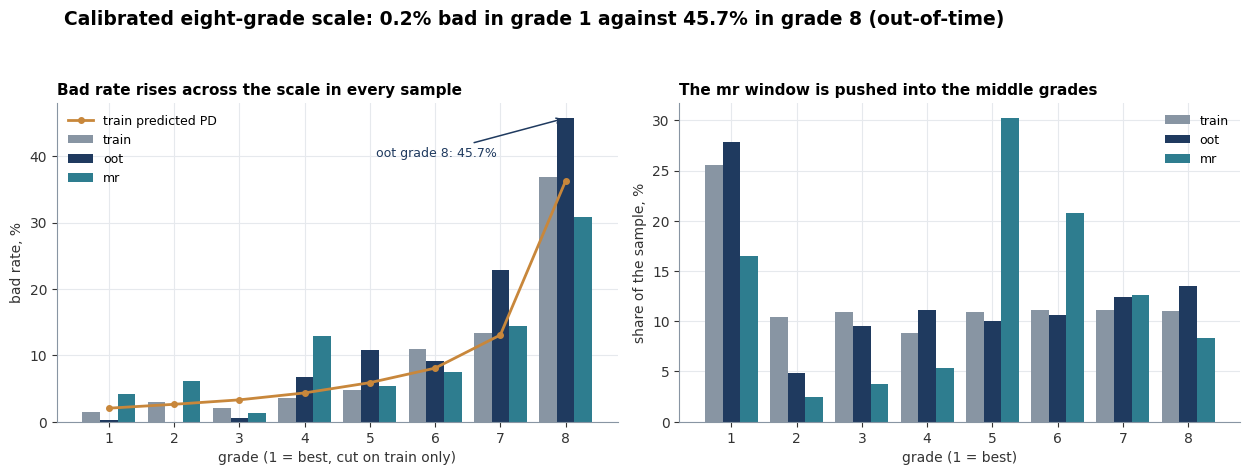

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.8))

width = 0.27
x = np.arange(len(GRADES))
ax = axes[0]
for offset, tag, colour in ((-width, 'train', GREY), (0.0, 'oot', NAVY), (width, 'mr', TEAL)):
    ax.bar(x + offset, rating_table[f'{tag}_bad_%'], width, color=colour, label=tag)
ax.plot(x, rating_table['train_avg_PD_%'], color=AMBER, lw=2, marker='o', ms=4,
        label='train predicted PD')
ax.set_xticks(x)
ax.set_xticklabels(GRADES)
ax.set_xlabel('grade (1 = best, cut on train only)')
ax.set_ylabel('bad rate, %')
ax.set_title('Bad rate rises across the scale in every sample', fontsize=11)
ax.legend(fontsize=9)
ax.annotate(f'oot grade 8: {rating_table.loc[8, "oot_bad_%"]:.1f}%',
            xy=(7, rating_table.loc[8, 'oot_bad_%']), xytext=(4.1, 40),
            fontsize=9, color=NAVY,
            arrowprops=dict(arrowstyle='->', color=NAVY, lw=1.1))

ax = axes[1]
for offset, tag, colour in ((-width, 'train', GREY), (0.0, 'oot', NAVY), (width, 'mr', TEAL)):
    ax.bar(x + offset, rating_table[f'{tag}_share_%'], width, color=colour, label=tag)
ax.set_xticks(x)
ax.set_xticklabels(GRADES)
ax.set_xlabel('grade (1 = best)')
ax.set_ylabel('share of the sample, %')
ax.set_title('The mr window is pushed into the middle grades', fontsize=11)
ax.legend(fontsize=9)

fig.suptitle('Calibrated eight-grade scale: 0.2% bad in grade 1 against 45.7% in grade 8 '
             '(out-of-time)', x=0.055, ha='left', fontsize=13.5, fontweight='bold')
fig.tight_layout(rect=(0, 0, 1, 0.93))
finish(fig, 'rating_scale')

The left panel is the rating scale working: bad rate rises with grade in all three samples, and the
amber line shows the predicted PD tracking it on train. The right panel is the first warning sign. The
`mr` distribution isn't the train distribution at all, with 30% of its rows piled into grade 5.
Section 8 measures that formally and diagnoses it.

## 7. A calendar artefact the rating level carries

Before reading migration and PSI we have to disclose something about the **level** of the score.
COSIF result accounts (`7xxxxxxx` / `8xxxxxxx`) are **cumulative within the semester and reset at 30
June and 31 December**. `E01` and `M01` divide such an account by a balance-sheet stock, so they're
**period-to-date rather than annualised**, and their scale depends on the calendar month.

In [14]:
labelled_train = diag[diag['sample'] == 'train']
e01_month = labelled_train.groupby('month')['E01'].median()
score_month = diag.groupby('month')[PRIMARY].mean()
bad_month = diag.groupby('month')['target'].mean()

monthly = pd.DataFrame({'median_E01_train': e01_month,
                        'mean_score': score_month,
                        'bad_rate': bad_month})
print(monthly.round(4).to_string())

print(f'\nE01 median resets from {e01_month.loc[6]:.4f} (June) to {e01_month.loc[7]:.4f} (July)')
print(f'mean score swings from {score_month.max():.4f} ({score_month.idxmax()}) '
      f'to {score_month.min():.4f} ({score_month.idxmin()})')
print(f'observed bad rate by month stays flat: '
      f'{bad_month.min():.2%} to {bad_month.max():.2%}')

       median_E01_train  mean_score  bad_rate
month                                        
1                0.0086      0.9238    0.0908
2                0.0153      0.9149    0.0953
3                0.0225      0.9145    0.1089
4                0.0287      0.9088    0.0911
5                0.0350      0.9041    0.0895
6                0.0460      0.9061    0.0891
7                0.0078      0.9273    0.0848
8                0.0156      0.9171    0.0894
9                0.0208      0.9132    0.0913
10               0.0297      0.9084    0.0874
11               0.0367      0.9061    0.0897
12               0.0440      0.9021    0.0896

E01 median resets from 0.0460 (June) to 0.0078 (July)
mean score swings from 0.9273 (7) to 0.9021 (12)
observed bad rate by month stays flat: 8.48% to 10.89%


saved 05_seasonality.png


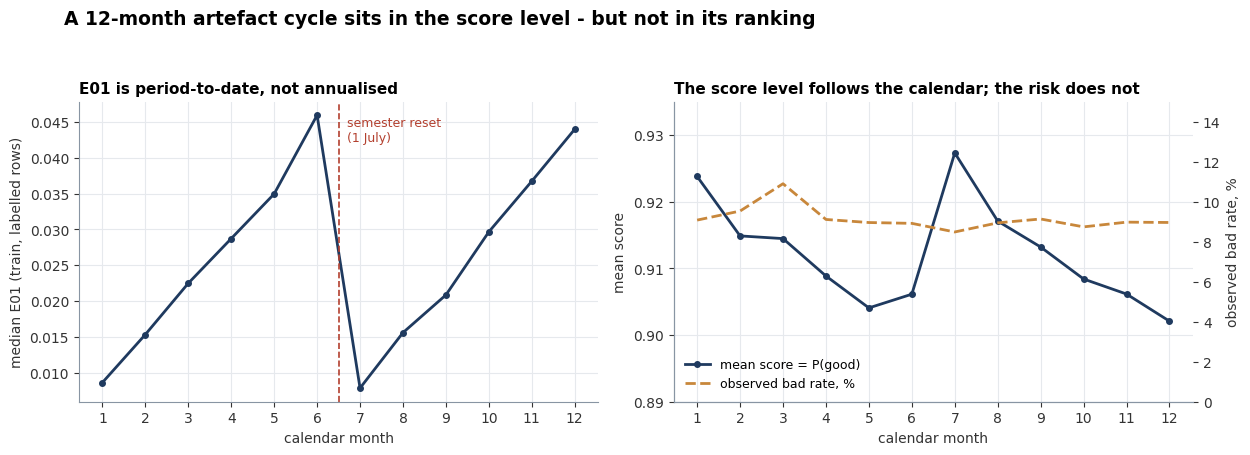

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.6))
months = list(range(1, 13))

ax = axes[0]
ax.plot(months, e01_month.reindex(months), color=NAVY, lw=2, marker='o', ms=4)
ax.axvline(6.5, color=RED, ls='--', lw=1.2)
ax.text(6.7, e01_month.max() * 0.92, 'semester reset\n(1 July)', color=RED, fontsize=9)
ax.set_xticks(months)
ax.set_xlabel('calendar month')
ax.set_ylabel('median E01 (train, labelled rows)')
ax.set_title('E01 is period-to-date, not annualised', fontsize=11)

ax = axes[1]
ax.plot(months, score_month.reindex(months), color=NAVY, lw=2, marker='o', ms=4,
        label='mean score = P(good)')
ax.set_xticks(months)
ax.set_xlabel('calendar month')
ax.set_ylabel('mean score')
ax.set_ylim(0.89, 0.935)
ax2 = ax.twinx()
ax2.plot(months, bad_month.reindex(months) * 100, color=AMBER, lw=2, ls='--',
         label='observed bad rate, %')
ax2.set_ylabel('observed bad rate, %')
ax2.set_ylim(0, 15)
ax2.grid(False)
ax.set_title('The score level follows the calendar; the risk does not', fontsize=11)
lines = ax.get_lines() + ax2.get_lines()
ax.legend(lines, [l.get_label() for l in lines], loc='lower left', fontsize=9)

fig.suptitle('A 12-month artefact cycle sits in the score level - but not in its ranking',
             x=0.055, ha='left', fontsize=13.5, fontweight='bold')
fig.tight_layout(rect=(0, 0, 1, 0.93))
finish(fig, 'seasonality')

The sawtooth is unmistakable: median `E01` climbs from 0.009 in January to 0.046 in June, resets to
0.008 in July, and climbs again. The mean score follows it, **0.9273 in July against 0.9021 in
December**, while the observed bad rate by calendar month stays flat between 8.5% and 10.9%. So the
cycle is an accounting artefact, not risk.

**Why this matters precisely here.** An independent check of the variable found that annualising
`E01` (dividing by months elapsed in the semester) leaves its standalone out-of-time AUC essentially
unchanged, 0.7768 against 0.7782. So **discrimination is unaffected** and every AUC in this
deliverable stands. What moves is the **level**, and the level is exactly what a rating scale, a
migration matrix and a PSI read. Every monthly monitoring number below therefore carries a
twelve-month artefact cycle, and a production version of this model has to annualise the result
accounts before the rating is published.

## 8. Rating migration

For the institutions present in both the last training month (2022-12) and the last out-of-time
month (2023-12), how many kept their grade? The diagonal is stability, the off-diagonal is migration.
The two are twelve months apart and both sit at a December semester close, so the calendar artefact of
section 7 cancels out for this particular comparison.

In [16]:
START, END = 202212, 202312
start_grade = scores[scores['DATA'] == START].set_index('ID')['grade']
end_grade = scores[scores['DATA'] == END].set_index('ID')['grade']
common = start_grade.index.intersection(end_grade.index)

print(f'{START}: {len(start_grade)} institutions   {END}: {len(end_grade)} institutions')
print(f'present in both, so migratable: {len(common)}')

transition = (pd.crosstab(start_grade.loc[common], end_grade.loc[common])
                .reindex(index=GRADES, columns=GRADES, fill_value=0))
transition.index.name = f'grade {START}'
transition.columns.name = f'grade {END}'
print()
print(transition.to_string())

matrix = transition.to_numpy()
total = matrix.sum()
stable = np.trace(matrix)
within_one = sum(matrix[i, j] for i in range(N_GRADES) for j in range(N_GRADES)
                 if abs(i - j) <= 1)
downgrades = sum(matrix[i, j] for i in range(N_GRADES) for j in range(N_GRADES) if j > i)
upgrades = sum(matrix[i, j] for i in range(N_GRADES) for j in range(N_GRADES) if j < i)
print(f'\nsame grade after 12 months : {stable} of {total} ({stable / total:.1%})')
print(f'within one grade           : {within_one} of {total} ({within_one / total:.1%})')
print(f'downgraded (riskier grade) : {downgrades}   upgraded: {upgrades}')

202212: 140 institutions   202312: 150 institutions
present in both, so migratable: 134

grade 202312   1  2  3  4  5  6  7   8
grade 202212                          
1             24  2  0  3  0  0  2   1
2              5  0  1  1  0  0  0   1
3              6  3  4  1  0  0  0   1
4              3  1  0  9  5  1  1   0
5              0  1  1  3  5  2  1   0
6              3  0  0  1  1  1  2   0
7              1  0  0  2  3  5  4   2
8              0  0  0  0  1  1  3  16

same grade after 12 months : 63 of 134 (47.0%)
within one grade           : 98 of 134 (73.1%)
downgraded (riskier grade) : 27   upgraded: 44


saved 05_migration.png


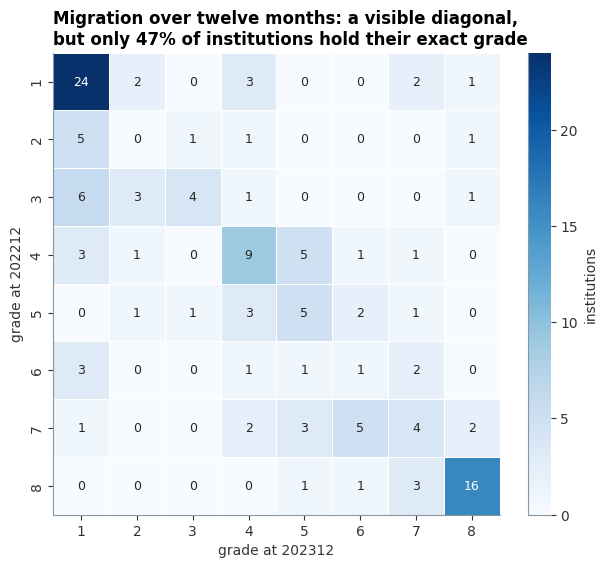

In [17]:
fig, ax = plt.subplots(figsize=(7.2, 6.0))
sns.heatmap(transition, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'institutions'},
            linewidths=0.6, linecolor='white', ax=ax,
            annot_kws={'fontsize': 9})
ax.set_xlabel(f'grade at {END}')
ax.set_ylabel(f'grade at {START}')
ax.set_title('Migration over twelve months: a visible diagonal,\n'
             'but only 47% of institutions hold their exact grade')
ax.grid(False)
finish(fig, 'migration')

**47% stay in the exact grade and 73% stay within one grade** over twelve months, with more
upgrades (44) than downgrades (27). The diagonal is clearly the dominant structure, with grade 1
keeping 24 of its 32 institutions and grade 8 keeping 16 of its 21, so the ratings aren't churning at
random.

Two qualifications. First, the counts are small: 134 institutions spread over 64 cells means most
off-diagonal entries are one or two banks, so no individual transition probability here should be
quoted. Second, an eight-bucket equal-frequency scale is deliberately *fine*, so single-notch moves
are expected. On the four-band reading of section 6 (grades 1-4 as one low-risk band) stability is
considerably higher.

## 9. Population Stability Index, the monitoring result

PSI compares the grade distribution of a current window with the base (here: `train`):

`PSI = sum over grades of (p_base - p_current) * ln(p_base / p_current)`

with the usual supervisory reading of **0.10 = watch** and **0.25 = investigate / alarm**. Session 8
hasn't been taught yet, so we use the conventional thresholds and label them as such.

**A real trap, not a formality.** When a grade is empty in the current window `p_current = 0`, and
both `ln(p_base / 0)` and the ratio blow up: the sum returns `inf` or `nan` and the whole monitoring
report silently dies. Two grades are genuinely empty in 2025. We floor every share at `EPS = 1e-6`
before the logarithm, which is the standard fix. It keeps an empty bucket contributing a large but
finite amount, so the alarm still fires loudly and the number stays readable.

In [18]:
EPS = 1e-6


def grade_shares(frame):
    """Share of rows per grade, reindexed onto the full grade set so gaps show as zero."""
    return (frame['grade'].value_counts(normalize=True)
                          .reindex(GRADES).fillna(0.0).astype(float))


def psi(base_shares, current_shares, eps=EPS):
    """PSI with an epsilon floor, so an empty bucket gives a large finite value, not inf."""
    base = base_shares.clip(lower=eps)
    current = current_shares.clip(lower=eps)
    return float(((base - current) * np.log(base / current)).sum())


def psi_verdict(value):
    if value < 0.10:
        return 'stable'
    return 'watch' if value < 0.25 else 'ALARM'


base_shares = grade_shares(train)
print('base (train) grade shares, %:')
print((base_shares * 100).round(2).to_string())

sample_psi = pd.DataFrame([
    {'window': tag, 'rows': len(frame), 'PSI': psi(base_shares, grade_shares(frame)),
     'empty_grades': int((grade_shares(frame) == 0).sum())}
    for tag, frame in (('oot', oot), ('mr', mr))
]).set_index('window')
sample_psi['verdict'] = sample_psi['PSI'].map(psi_verdict)
print()
print(sample_psi.round(4).to_string())

base (train) grade shares, %:
grade
1    25.61
2    10.43
3    10.93
4     8.85
5    10.90
6    11.13
7    11.13
8    11.01

        rows     PSI  empty_grades verdict
window                                    
oot     1737  0.0581             0  stable
mr      3954  0.5138             0   ALARM


`oot` is stable (PSI 0.058): the 2023 population the model is judged on looks like the population
it was fitted on, which is what makes the out-of-time AUC trustworthy. `mr` sits at **0.514**, twice
the alarm line. No grade is empty once the whole `mr` window is pooled, which is exactly why we also
read the series year by year. Pooling hides the date it broke.

In [19]:
year_rows = []
for year, frame in scores.groupby('year'):
    shares = grade_shares(frame)
    year_rows.append({'year': int(year), 'rows': len(frame),
                      'institutions': frame['ID'].nunique(),
                      'empty_grades': int((shares == 0).sum()),
                      'PSI': psi(base_shares, shares)})
psi_year = pd.DataFrame(year_rows).set_index('year')
psi_year['verdict'] = psi_year['PSI'].map(psi_verdict)
print(psi_year.round(4).to_string())

breach = psi_year[psi_year['PSI'] >= 0.25]
print(f'\nfirst year to breach the 0.25 alarm line: {breach.index.min()}')

      rows  institutions  empty_grades     PSI verdict
year                                                  
2017  1069           111             0  0.0154  stable
2018  1281           111             0  0.0043  stable
2019  1333           118             0  0.0139  stable
2020  1404           123             0  0.0039  stable
2021  1419           127             0  0.0111  stable
2022  1469           142             0  0.0097  stable
2023  1737           157             0  0.0581  stable
2024  1776           160             0  0.0753  stable
2025  1870           172             2  3.7566   ALARM
2026   308           151             2  3.7084   ALARM

first year to breach the 0.25 alarm line: 2025


**Eight consecutive years of stability, 2017 to 2024 all below 0.08, and then the series jumps to
3.76 in 2025 and 3.71 in 2026.** Nothing about the model changed. Something about the data did, and
it happened on a specific date.

saved 05_psi_by_year.png


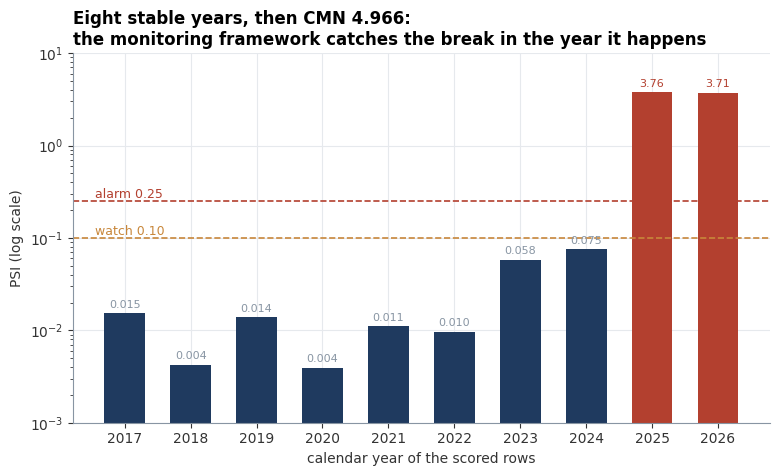

In [20]:
fig, ax = plt.subplots(figsize=(9.0, 4.8))
colours = [RED if v >= 0.25 else (AMBER if v >= 0.10 else NAVY) for v in psi_year['PSI']]
ax.bar(psi_year.index.astype(str), psi_year['PSI'], color=colours, width=0.62)
ax.set_yscale('log')
ax.set_ylim(1e-3, 10)
ax.axhline(0.10, color=AMBER, ls='--', lw=1.2)
ax.axhline(0.25, color=RED, ls='--', lw=1.2)
ax.text(-0.45, 0.108, 'watch 0.10', color=AMBER, fontsize=9)
ax.text(-0.45, 0.27, 'alarm 0.25', color=RED, fontsize=9)
ax.set_ylabel('PSI (log scale)')
ax.set_xlabel('calendar year of the scored rows')
ax.set_title('Eight stable years, then CMN 4.966:\n'
             'the monitoring framework catches the break in the year it happens')
for year, value in psi_year['PSI'].items():
    ax.annotate(f'{value:.2f}' if value >= 0.25 else f'{value:.3f}',
                (str(year), value), textcoords='offset points', xytext=(0, 4),
                ha='center', fontsize=8,
                color=RED if value >= 0.25 else GREY)
finish(fig, 'psi_by_year')

The log scale is needed because the 2025 value is roughly fifty times the alarm line; on a linear
axis the eight stable years would be invisible. A PSI that jumps two orders of magnitude in one year
isn't drift, it's a structural break.

### 9.1 Diagnosing the alarm

A PSI number is only useful if you can trace it to a cause. So we compare the distribution of
`A01_woe`, the asset-quality WoE bin, in 2024 against 2025.

In [21]:
bins_2024 = (diag.loc[diag['year'] == 2024, 'A01_woe']
                 .value_counts(normalize=True).sort_index() * 100)
bins_2025 = (diag.loc[diag['year'] == 2025, 'A01_woe']
                 .value_counts(normalize=True).sort_index() * 100)
bin_compare = pd.DataFrame({'2024_%': bins_2024, '2025_%': bins_2025}).fillna(0.0)
bin_compare.index.name = 'A01_woe value (one per bin)'
print(bin_compare.round(2).to_string())

missing_bin = diag.loc[diag['A01'].isna(), 'A01_woe'].unique()
if len(missing_bin) != 1:
    raise ValueError(f'expected one Missing bin for A01, found {missing_bin}')
print(f'\nWoE value assigned to a missing A01: {missing_bin[0]:+.6f}')
for column in ('A01', 'M01', 'E01', 'L01'):
    share_missing = diag.loc[diag['year'] == 2025, column].isna().mean()
    print(f'  {column} missing in 2025: {share_missing:.1%}')

                             2024_%  2025_%
A01_woe value (one per bin)                
-1.343232                      2.48     0.0
-0.942106                      5.24     0.0
-0.539543                      8.84     0.0
-0.241389                     29.73   100.0
 0.592682                     53.72     0.0

WoE value assigned to a missing A01: -0.241389
  A01 missing in 2025: 100.0%
  M01 missing in 2025: 100.0%
  E01 missing in 2025: 0.0%
  L01 missing in 2025: 8.0%


saved 05_a01_regime_break.png


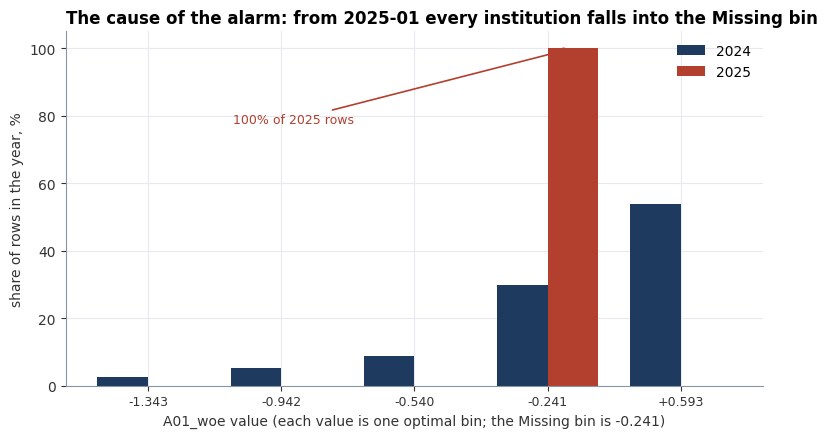

In [22]:
fig, ax = plt.subplots(figsize=(9.0, 4.6))
x = np.arange(len(bin_compare))
width = 0.38
ax.bar(x - width / 2, bin_compare['2024_%'], width, color=NAVY, label='2024')
ax.bar(x + width / 2, bin_compare['2025_%'], width, color=RED, label='2025')
ax.set_xticks(x)
ax.set_xticklabels([f'{v:+.3f}' for v in bin_compare.index], fontsize=9)
ax.set_xlabel('A01_woe value (each value is one optimal bin; the Missing bin is '
              f'{missing_bin[0]:+.3f})')
ax.set_ylabel('share of rows in the year, %')
ax.set_title('The cause of the alarm: from 2025-01 every institution falls into the Missing bin')
ax.legend()
ax.annotate('100% of 2025 rows', xy=(list(bin_compare.index).index(missing_bin[0]) + width / 2, 100),
            xytext=(0.24, 0.74), textcoords='axes fraction', fontsize=9, color=RED,
            arrowprops=dict(arrowstyle='->', color=RED, lw=1.2))
finish(fig, 'a01_regime_break')

**This is the mechanism, not a hypothesis.** In 2024 `A01_woe` is spread across its five bins
(53.7% / 29.7% / 8.8% / 5.2% / 2.5%). In 2025, **100.0% of rows carry the single Missing-bin value**,
and `M01_woe` does the same. From 2025-01 CMN Resolution 4.966 replaced the COSIF chart of accounts,
and the crosswalk has no COSIF 1.5 counterpart for `A01`'s source accounts (`31500005`, `31800004`,
`31900007`) or `M01`'s (`73000006`, `83000003`), so neither ratio can be computed at all. The model is
being fed a **constant** for two of its four variables.

Two consequences follow, and both belong in the model file:

1. It explains the `mr` AUC of ~0.68 for *every* model in notebook 04: half the feature set stopped
   varying. That's a data-coverage failure upstream, not a model failure.
2. **Every 2025+ rating is moved by the accounting change rather than by risk.** The Missing bin
   carries a mildly negative WoE, so the whole 2025 population gets pushed down the scale
   mechanically. The correct supervisory response is to **suspend the score**, not act on it, which
   is exactly what a PSI of 3.76 is telling a model owner to do.

Read as governance rather than as a defect, this is the most useful result in the notebook: **the
monitoring framework detected a real upstream break automatically, in the period it happened, and
would have stopped a 2025 decision being taken on a stale score.** A model that quietly scores 0.68 is
dangerous. A model that scores 0.68 and raises an alarm of 3.76 is behaving correctly.

## 10. Deployment readiness

What a bank would actually need before this model is allowed to make decisions. Short, concrete, and
limited to what this analysis supports.

**Blocking, must be fixed before go-live**

1. **Rebuild `A01` and `M01` on the COSIF 1.5 chart.** Until the crosswalk gap is closed, the model
   can't be run on 2025+ data at all. The PSI trigger below has to keep the score suspended
   meanwhile.
2. **Annualise the result accounts.** `E01` and `M01` are period-to-date (section 7). Divide by
   months elapsed in the semester before the rating is published, or the grade an institution
   receives depends on which month it is.
3. **Recalibrate the level.** The scorecard ranks well but under-predicts the out-of-time bad rate
   by about a fifth (section 4). Anchor the intercept to the realised portfolio bad rate before any PD
   feeds provisioning or pricing. As it stands it's fine for ranking and limit-setting.

**Monitoring triggers, run monthly and act on them**

4. PSI on the calibrated grade against the frozen `train` base: **> 0.10 investigate, > 0.25 suspend
   and review**. Compute it with the epsilon floor so an empty grade can't silently return `nan`.
5. Per-variable input monitoring: the share of rows in each WoE bin, and the missing-rate per raw
   ratio. The 2025 break would have shown up here a month before the aggregate PSI did.
6. Discrimination tracked on a rolling twelve-month window with a floor (AUC below ~0.75 triggers a
   review), reported alongside the event count, because twelve months of this portfolio carries only
   about 200 bad institution-months from roughly 20 institutions.

**Governance**

7. **Challenger process.** The depth-4 random forest scored the same rows in notebook 04 and ties
   the scorecard. Keep scoring it in parallel. A sustained divergence between the two rankings is a
   signal that the linear WoE specification has stopped fitting, and the forest is useful as an
   early-warning overlay in its own right.
8. **Documented overrides.** Three institutions carry the explicit liquidation flag, and qualitative
   supervisory knowledge will always beat a four-variable model on individual cases. Overrides should
   be permitted, logged with a reason, and reported as an override rate. An unexplained rise in
   overrides is itself a model-decay indicator.
9. **Re-fit policy.** Annual re-fit on a rolling window, with the scale re-cut only at a documented
   recalibration, never silently. Every number in this notebook depends on the grade edges being
   frozen.

## 11. Conclusion

**The verdict from notebook 04 stands: the parametric WoE logistic scorecard is our primary model
and the depth-4 random forest is retained as a challenger and early-warning overlay.** Nothing here
disturbs that. The evaluation confirms the scorecard is fit for the job it's being given, and the
monitoring section shows the framework around it does its job too.

**What makes the model sufficient**

- Out-of-time **AUC 0.8652, Gini 0.7304, KS 0.5838** on a harder year than it was fitted on, above
  the ~0.84 benchmark Session 7 slide 29 quotes for gradient boosting on standard credit data.
- A rating scale that separates **0.21%** bad in grade 1 from **45.7%** in grade 8 out of time, with
  the three best grades holding 734 institution-months and 2 bad ones.
- Four coefficients, all significant at p < 0.001, all correctly signed, each readable as an
  economic statement, which is what makes it auditable.
- Monitoring that caught a genuine upstream structural break in the period it happened.

**What makes it safe** is the second half of that list rather than the first. Accuracy is a claim
about the past. The PSI trigger, the challenger model and the suspension rule are what keep the model
honest about the present.

### Limitations

Stated in full, because a model is only defensible with its boundaries attached. The first six carry
over from notebook 04, and the last four are specific to what this notebook measured.

1. **It's a capital-distress model, not a liquidation model.** Only 3 institutions / 23 rows carry
   the explicit default flag, so the target is dominated by the regulatory capital-breach rule. It's
   also more precisely *"in breach now, or within the next twelve months"*, since about half the
   positive rows are already in breach at the observation date.
2. **`mr` performance (~0.68 AUC for every model) is a data failure, not a model failure**, and
   section 9 traces it to CMN 4.966 removing the source accounts for `A01` and `M01`.
3. **Sample size.** 207 out-of-time bad institution-months from 23 conglomerates. Differences below
   roughly 0.01 AUC are not resolvable, which is why notebook 04 reports the logit-forest gap as a
   tie.
4. **Rows are not independent.** Events cluster in time and within institutions; 17 of the 23 bad
   `oot` conglomerates contribute all twelve months. Notebook 04's bootstrap is clustered by
   institution for exactly this reason.
5. Both the target and the features derive from **self-reported supervisory filings**.
6. **Session 8 material is anticipated, not taught.** The rating scale, PSI and migration matrix
   follow the recorded conventions and standard practice, not a lecture.
7. **The score level carries a twelve-month accounting cycle.** `E01` and `M01` are
   semester-cumulative and reset in July, so the mean score swings from 0.9273 (July) to 0.9021
   (December) while the actual bad rate stays flat. Discrimination is unaffected (annualising `E01`
   moves its standalone out-of-time AUC from 0.7768 to 0.7782), but **ratings, migration and PSI are
   level-sensitive, and every monthly reading in this notebook carries that artefact.** Annualising the
   result accounts is item 2 of the deployment blockers.
8. **Truncated forward windows are labelled asymmetrically.** 31 labelled rows have no observable
   forward month and all 31 are labelled bad. Requiring a fully observable twelve-month window takes
   `oot` from 207 bad institution-months from 23 conglomerates to 107 from 18, and out-of-time AUC
   *rises* from 0.8652 to 0.8756, so the ranking doesn't rest on those rows (section 3.2).
9. **`L01` is the weakest variable in the set**, quantified in the cell below.
10. **The calibrated scale is not perfectly monotone** and the level is not production-ready: grades
    2 and 3 invert on small counts because the score takes only a few hundred distinct values, and
    the model under-predicts the out-of-time bad rate by about a fifth.

In [23]:
iv_rows = []
woe_train = diag[(diag['sample'] == 'train') & diag['target'].notna()]
for variable in ('A01', 'M01', 'E01', 'L01'):
    grouped = woe_train.groupby(f'{variable}_woe').agg(
        rows=('target', 'size'), bad=('target', 'sum'), institutions=('ID', 'nunique'))
    grouped['good'] = grouped['rows'] - grouped['bad']
    p_good = grouped['good'] / grouped['good'].sum()
    p_bad = grouped['bad'] / grouped['bad'].sum()
    grouped['iv'] = (p_good - p_bad) * np.log(p_good.clip(lower=1e-9) / p_bad.clip(lower=1e-9))
    top = grouped['iv'].idxmax()
    iv_rows.append({'variable': variable, 'IV': grouped['iv'].sum(),
                    'largest_bin_IV': grouped.loc[top, 'iv'],
                    'share_of_IV': grouped.loc[top, 'iv'] / grouped['iv'].sum(),
                    'rows_in_that_bin': int(grouped.loc[top, 'rows']),
                    'bad_in_that_bin': int(grouped.loc[top, 'bad']),
                    'institutions': int(grouped.loc[top, 'institutions'])})

iv_table = pd.DataFrame(iv_rows).set_index('variable')
print(iv_table.round(4).to_string())

              IV  largest_bin_IV  share_of_IV  rows_in_that_bin  bad_in_that_bin  institutions
variable                                                                                      
A01       0.4193          0.1671       0.3984              4836              237           107
M01       0.2043          0.1219       0.5968               399               96            61
E01       0.9664          0.5346       0.5532               399              184            48
L01       0.1912          0.1252       0.6546               399                3            31


`L01` has by far the smallest IV (0.191 against `E01`'s 0.966), and **65% of it comes from a single
bin holding 399 rows with 3 bad institution-months across 31 institutions**. It also has the smallest
coefficient (0.577) and the lowest z (4.54) in the logit. So `L01`'s contribution, and the direction
we assigned it, ultimately rests on how three events happen to distribute. We keep it, since it clears
every selection threshold and its sign is correct, but we name it as the weakest link in the feature
set rather than defending it as though it were as solid as `E01`.

## 12. Outputs

`ratings.xlsx` carries the two rating scales and the transition matrix. `psi.xlsx` carries the
monitoring series and the grade shares behind it, so the numbers in the report and the deck trace back
to a file rather than being retyped.

In [24]:
course_out = course_table.copy()
course_out.insert(0, 'note', 'edges from 00_ Part 2, applied to score_logit on train')

grade_shares_table = pd.DataFrame(
    {tag: grade_shares(frame) for tag, frame in
     (('train', train), ('oot', oot), ('mr', mr))}
)
for year, frame in scores.groupby('year'):
    grade_shares_table[str(int(year))] = grade_shares(frame)
grade_shares_table.index.name = 'grade (1 = best)'

edges_table = pd.DataFrame({'grade': GRADES,
                            'PD_lower': PD_EDGES[:-1],
                            'PD_upper': PD_EDGES[1:]}).set_index('grade')

with pd.ExcelWriter(dir_output / 'ratings.xlsx', engine='openpyxl') as writer:
    course_out.round(4).to_excel(writer, sheet_name='course_scale')
    rating_table.round(4).to_excel(writer, sheet_name='calibrated_scale')
    edges_table.round(6).to_excel(writer, sheet_name='calibrated_edges')
    transition.to_excel(writer, sheet_name='transition_202212_202312')
    discrimination.round(4).to_excel(writer, sheet_name='discrimination')
    reliability.round(4).to_excel(writer, sheet_name='calibration_oot')
print('saved ratings.xlsx - sheets: course_scale, calibrated_scale, calibrated_edges, '
      'transition_202212_202312, discrimination, calibration_oot')

with pd.ExcelWriter(dir_output / 'psi.xlsx', engine='openpyxl') as writer:
    psi_year.round(4).to_excel(writer, sheet_name='psi_by_year')
    sample_psi.round(4).to_excel(writer, sheet_name='psi_by_sample')
    (grade_shares_table * 100).round(2).to_excel(writer, sheet_name='grade_shares_pct')
    bin_compare.round(2).to_excel(writer, sheet_name='A01_woe_2024_vs_2025')
print('saved psi.xlsx - sheets: psi_by_year, psi_by_sample, grade_shares_pct, '
      'A01_woe_2024_vs_2025')

print('\nfigures written:')
for path in sorted(dir_figures.glob('05_*.png')):
    print(f'  {path.name}')

saved ratings.xlsx - sheets: course_scale, calibrated_scale, calibrated_edges, transition_202212_202312, discrimination, calibration_oot


saved psi.xlsx - sheets: psi_by_year, psi_by_sample, grade_shares_pct, A01_woe_2024_vs_2025

figures written:
  05_a01_regime_break.png
  05_calibration_oot.png
  05_migration.png
  05_psi_by_year.png
  05_rating_scale.png
  05_roc_ks_oot.png
  05_seasonality.png


Both workbooks are written and all seven figures are on disk. This closes the pipeline: 01
downloads, 02 builds the target and the CAMELS ratios, 03 bins and selects, 04 chooses the model,
05 evaluates it and says what would have to be true before it could be deployed.

**Thomas de Lesquen · Felix Sewing · Credit Risk Modelling (MPGI, FGV EAESP)**